# Quorum personality and guessing game analysis

This notebook reads the simulated export directly from `../simulated_data.zip` and summarizes lobby-task, guessing-feedback, and synchronization evidence.

In [1]:
from pathlib import Path
from zipfile import ZipFile
import ast
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 50
zip_path = Path('../simulated_data.zip')
assert zip_path.exists(), zip_path

def read_csv(name):
    with ZipFile(zip_path) as z:
        with z.open(name) as f:
            return pd.read_csv(f)

lobby = read_csv('data/simulated_data/regular/basic_data/lobby_trial.csv')
participants = read_csv('data/simulated_data/regular/basic_data/participant.csv')
sync_groups = read_csv('data/simulated_data/regular/data/SimpleSyncGroup.csv')
links = read_csv('data/simulated_data/regular/data/ParticipantLinkSyncGroup.csv')
barriers = read_csv('data/simulated_data/regular/data/BarrierRecord.csv')
answers = pd.json_normalize(lobby['answer'].apply(ast.literal_eval)).add_prefix('answer_')
lobby = pd.concat([lobby.drop(columns=['answer']), answers], axis=1)
lobby.head()

,trial_id,participant_id,node_id,trial_maker_id,task_type,lobby_index,item_id,item_key,facet,round_id,...,answer_response,answer_response_label,answer_participant_id,answer_trial_id,answer_node_id,answer_round_id,answer_target,answer_guess,answer_abs_diff,answer_feedback_label
0,1,1,1,productive_lobby,personality,1,1.0,E1,Friendliness,NaN,...,5,Very accurate,1,1,1,NaN,NaN,NaN,NaN,NaN
1,2,1,2,productive_lobby,personality,2,2.0,A1,Trust,NaN,...,5,Very accurate,1,2,2,NaN,NaN,NaN,NaN,NaN
2,3,1,3,productive_lobby,personality,3,3.0,C1,Self-Efficacy,NaN,...,5,Very accurate,1,3,3,NaN,NaN,NaN,NaN,NaN
3,4,1,4,productive_lobby,personality,4,4.0,N1,Anxiety,NaN,...,5,Very accurate,1,4,4,NaN,NaN,NaN,NaN,NaN
4,17,2,2,productive_lobby,personality,2,2.0,A1,Trust,NaN,...,4,Somewhat accurate,2,17,2,NaN,NaN,NaN,NaN,NaN


## Lobby coverage

The simulation should include productive waiting trials rather than idle pages. The serial bot path intentionally reaches both personality and guessing stages before quorum forms.

In [2]:
coverage = (
    lobby.groupby('task_type')
    .agg(n_trials=('trial_id', 'count'), n_participants=('participant_id', 'nunique'))
    .reset_index()
)
coverage

,task_type,n_trials,n_participants
0,guessing,5,1
1,personality,16,4


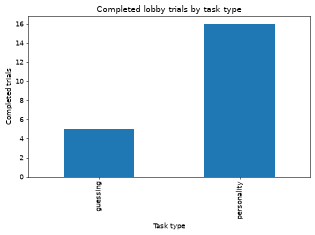

In [3]:
ax = coverage.plot.bar(x='task_type', y='n_trials', legend=False, title='Completed lobby trials by task type')
ax.set_xlabel('Task type')
ax.set_ylabel('Completed trials')
plt.tight_layout()

## Personality item recording

Personality rows should store item identifiers and response labels for the short Big Five items.

In [4]:
personality = lobby[lobby['task_type'] == 'personality']
personality[['participant_id', 'lobby_index', 'item_id', 'item_key', 'facet', 'answer_response_label']].head(12)

,participant_id,lobby_index,item_id,item_key,facet,answer_response_label
0,1,1,1.0,E1,Friendliness,Very accurate
1,1,2,2.0,A1,Trust,Very accurate
2,1,3,3.0,C1,Self-Efficacy,Very accurate
3,1,4,4.0,N1,Anxiety,Very accurate
4,2,2,2.0,A1,Trust,Somewhat accurate
5,2,1,1.0,E1,Friendliness,Neither accurate nor inaccurate
6,1,6,6.0,E2,Gregariousness,Very accurate
7,3,1,1.0,E1,Friendliness,Somewhat accurate
8,1,5,5.0,O1,Imagination,Very accurate
9,1,9,9.0,N2,Anger,Very accurate


## Guessing feedback

Guessing rows should hide the target until submission but save the target, guess, absolute difference, and feedback label. The simulated profile covers exact, difference-1, difference-2, and greater-than-2 outcomes.

In [5]:
guessing = lobby[lobby['task_type'] == 'guessing'].copy()
guessing[['participant_id', 'round_id', 'target', 'answer_guess', 'answer_abs_diff', 'answer_feedback_label']]

,participant_id,round_id,target,answer_guess,answer_abs_diff,answer_feedback_label
15,1,2.0,6.0,8.0,2.0,A little warmer
16,1,1.0,10.0,9.0,1.0,Warmer
17,1,4.0,9.0,9.0,0.0,Correct! You guessed the hidden target exactly.
18,1,3.0,2.0,5.0,3.0,Cold
19,1,5.0,5.0,6.0,1.0,Warmer


In [6]:
feedback_counts = guessing['answer_feedback_label'].value_counts().rename_axis('feedback_label').reset_index(name='n')
feedback_counts

,feedback_label,n
0,Warmer,2
1,A little warmer,1
2,Correct! You guessed the hidden target exactly.,1
3,Cold,1


## Quorum and recovery records

The export should show a native `SimpleGrouper`, participant links to the quorum group, and a simulated failure used to exercise recovery/top-up behavior.

In [7]:
participants

,participant_id,status,failed,failed_reason
0,1,working,True,simulated_failure
1,3,approved,False,NaN
2,2,approved,False,NaN
3,4,approved,False,NaN


In [8]:
sync_summary = {
    'sync_groups': len(sync_groups),
    'participant_group_links': len(links),
    'barrier_records': len(barriers),
    'min_group_size': int(sync_groups['min_group_size'].iloc[0]),
    'join_existing_groups': bool(sync_groups['accepts_top_ups'].iloc[0]),
}
sync_summary

{'sync_groups': 1,
 'participant_group_links': 4,
 'barrier_records': 1,
 'min_group_size': 3,
 'join_existing_groups': True}

## Interpretation

The simulated export confirms that waiting participants complete analytically separate lobby trials, the lobby includes personality and guessing stages, all required guessing feedback labels are represented, and synchronization data is produced by PsyNet native quorum/group records. One bot is deliberately failed in the regression scenario to exercise the under-quorate recovery path; the remaining participants complete successfully.